# SHINE_SWE_Pro Dataset Analysis

This notebook provides comprehensive analysis of the SHINE_SWE_Pro dataset:
1. **Repo Statistics**: Number of repos, trajectories per repo, correctness breakdown
2. **Token Length Distribution**: Using Qwen3.6-27B tokenizer with parallel processing
   - Per repo / per role (system, user, assistant, tool)
   - Summary tables with mean, max, min
3. **Model Statistics**: Breakdown by model used for trajectory generation

In [1]:
import json
import os
import sys
import time
from pathlib import Path
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data/SHINE_SWE_Pro')
MODEL_DIR = '../models/Qwen3.6-27B'

jsonl_file = DATA_DIR / 'SWE_Pro-trajs.openai.jsonl'
print(f'Data directory: {DATA_DIR}')
print(f'JSONL file: {jsonl_file.name}')
size = jsonl_file.stat().st_size
size_str = f'{size/1e9:.2f} GB' if size > 1e9 else f'{size/1e6:.2f} MB'
print(f'File size: {size_str}')

Data directory: ../data/SHINE_SWE_Pro
JSONL file: SWE_Pro-trajs.openai.jsonl
File size: 57.48 MB


## 1. Load Tokenizer (Qwen3.6-27B)

In [2]:
from transformers import AutoTokenizer

print(f'Loading tokenizer from: {MODEL_DIR}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, trust_remote_code=True)
print(f'Tokenizer loaded: vocab_size={tokenizer.vocab_size}')
print(f'Tokenizer type: {type(tokenizer).__name__}')

/opt/conda/envs/torch-base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/torch-base/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading tokenizer from: ../models/Qwen3.6-27B
Tokenizer loaded: vocab_size=248044
Tokenizer type: TokenizersBackend


## 2. Data Loading & Tokenization

Since SHINE_SWE_Pro is relatively small (340 samples, ~55MB), we load all data and tokenize directly.
Each sample's metadata (source_dataset, repo, correctness, model, resolved) and per-message token lengths are extracted.

In [3]:
import threading

NUM_TOKENIZE_WORKERS = min(64, cpu_count())

def process_sample(line, encode_fn):
    """Process a single JSONL line: parse JSON and tokenize all messages."""
    try:
        d = json.loads(line)
        messages = d.get('messages') or []
        source_dataset = d.get('source_dataset') or 'unknown'
        repo = d.get('repo') or 'unknown'
        correctness = d.get('correctness') or 'unknown'
        instance_id = d.get('instance_id') or ''
        trajectory_id = d.get('trajectory_id') or ''
        model = d.get('model') or 'unknown'
        resolved = d.get('resolved')
        
        msg_token_info = []
        for msg in messages:
            role = msg.get('role') or 'unknown'
            content = msg.get('content') or ''
            token_count = len(encode_fn(content))
            msg_token_info.append((role, token_count))
        
        return {
            'source_dataset': source_dataset,
            'repo': repo,
            'correctness': correctness,
            'instance_id': instance_id,
            'trajectory_id': trajectory_id,
            'model': model,
            'resolved': resolved,
            'msg_token_info': msg_token_info,
            'num_messages': len(messages),
        }
    except Exception as e:
        print(f'Error processing sample: {e}')
        return None

print(f'Processing {jsonl_file.name} with {NUM_TOKENIZE_WORKERS} workers...')
start_time = time.time()

# Read all lines
with open(jsonl_file, 'r', encoding='utf-8') as fp:
    lines = fp.readlines()

print(f'Loaded {len(lines):,} lines from file.')

# Process in parallel using ThreadPoolExecutor
all_data = []
encode_fn = tokenizer.encode

with ThreadPoolExecutor(max_workers=NUM_TOKENIZE_WORKERS) as executor:
    futures = {executor.submit(process_sample, line, encode_fn): idx 
               for idx, line in enumerate(lines)}
    for future in as_completed(futures):
        result = future.result()
        if result is not None:
            all_data.append(result)

elapsed = time.time() - start_time
print(f'\nDone! Processed {len(all_data):,} samples in {elapsed:.1f}s')
print(f'Unique repos: {len(set(s["repo"] for s in all_data))}')
print(f'Unique models: {len(set(s["model"] for s in all_data))}')

Processing SWE_Pro-trajs.openai.jsonl with 64 workers...
Loaded 340 lines from file.

Done! Processed 340 samples in 2.1s
Unique repos: 9
Unique models: 1


## 3. Repo Statistics

For each repo:
- How many trajectories
- How many correct / incorrect / unknown
- Resolved rate

In [4]:
# Build per-repo statistics
repo_stats = defaultdict(lambda: Counter())
repo_resolved = defaultdict(lambda: {'resolved': 0, 'unresolved': 0})

for sample in all_data:
    repo = sample['repo']
    correctness = sample['correctness']
    repo_stats[repo][correctness] += 1
    if sample['resolved']:
        repo_resolved[repo]['resolved'] += 1
    else:
        repo_resolved[repo]['unresolved'] += 1

# Summary table
print('=' * 110)
print(f'{"Repo":<45} {"#Trajectories":>14} {"#Correct":>9} {"#Incorrect":>11} {"#Unknown":>9} {"Resolved%":>10}')
print('=' * 110)

summary_rows = []
sorted_repos = sorted(repo_stats.items(), key=lambda x: sum(x[1].values()), reverse=True)
for repo, counts in sorted_repos:
    total = sum(counts.values())
    correct = counts.get('correct', 0)
    incorrect = counts.get('incorrect', 0)
    unknown = total - correct - incorrect
    resolved = repo_resolved[repo]['resolved']
    resolved_pct = resolved / total * 100 if total > 0 else 0
    print(f'{repo:<45} {total:>14,} {correct:>9,} {incorrect:>11,} {unknown:>9,} {resolved_pct:>9.1f}%')
    summary_rows.append({
        'Repo': repo, '#Trajectories': total,
        '#Correct': correct, '#Incorrect': incorrect, '#Unknown': unknown,
        'Resolved%': resolved_pct
    })

print('=' * 110)
total_all = len(all_data)
total_correct = sum(r['#Correct'] for r in summary_rows)
total_incorrect = sum(r['#Incorrect'] for r in summary_rows)
total_unknown = sum(r['#Unknown'] for r in summary_rows)
total_resolved = sum(repo_resolved[r]['resolved'] for r in repo_resolved)
total_resolved_pct = total_resolved / total_all * 100 if total_all > 0 else 0
print(f'{"TOTAL":<45} {total_all:>14,} {total_correct:>9,} {total_incorrect:>11,} {total_unknown:>9,} {total_resolved_pct:>9.1f}%')

Repo                                           #Trajectories  #Correct  #Incorrect  #Unknown  Resolved%
element-hq/element-web                                    56        52           4         0      92.9%
qutebrowser/qutebrowser                                   50        34          16         0      68.0%
NodeBB/NodeBB                                             40        20          20         0      50.0%
flipt-io/flipt                                            38        34           4         0      89.5%
internetarchive/openlibrary                               35        21          14         0      60.0%
ansible/ansible                                           33        27           6         0      81.8%
navidrome/navidrome                                       33        32           1         0      97.0%
gravitational/teleport                                    30        20          10         0      66.7%
future-architect/vuls                                     25    

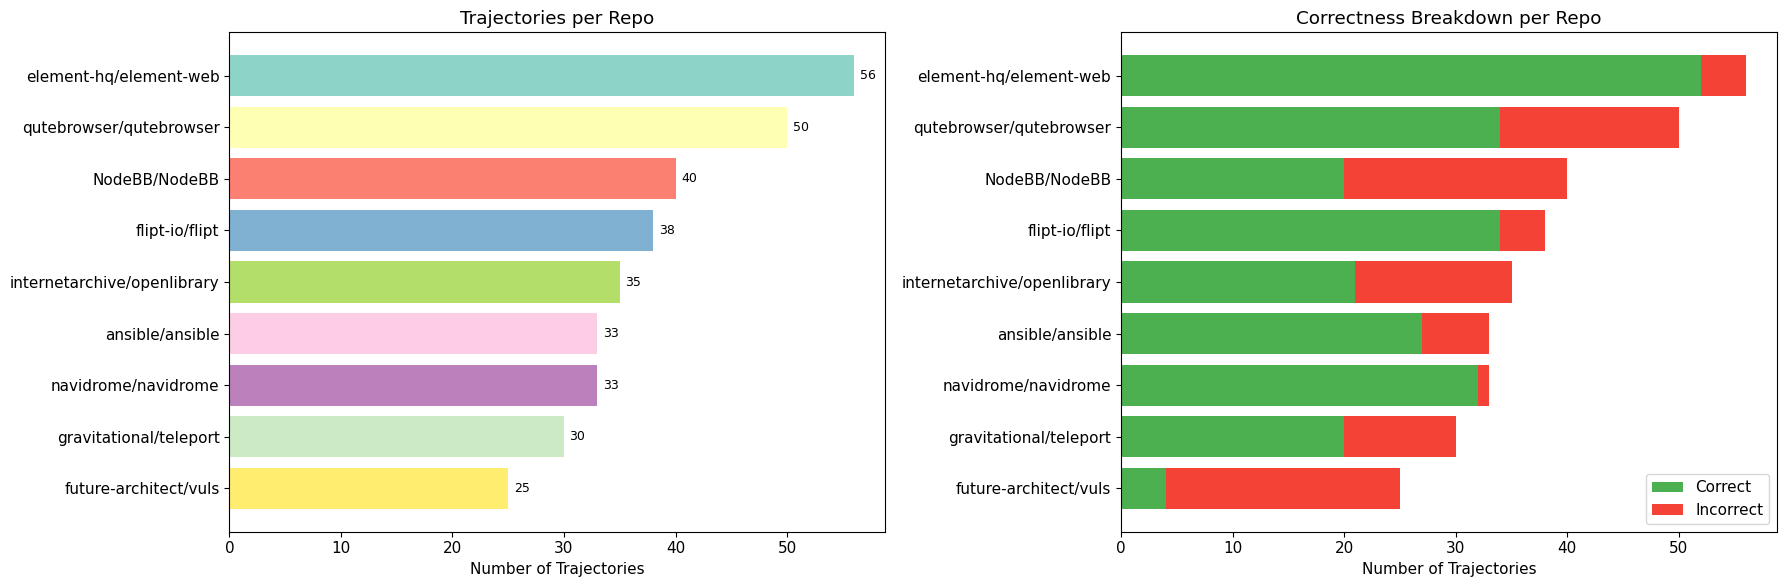

In [5]:
# Visualization: Trajectories per repo (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Trajectory count per repo
repos_sorted = [r['Repo'] for r in sorted(summary_rows, key=lambda x: x['#Trajectories'], reverse=True)]
counts_sorted = [r['#Trajectories'] for r in sorted(summary_rows, key=lambda x: x['#Trajectories'], reverse=True)]

colors = plt.cm.Set3(np.linspace(0, 1, len(repos_sorted)))
axes[0].barh(repos_sorted, counts_sorted, color=colors)
axes[0].set_xlabel('Number of Trajectories')
axes[0].set_title('Trajectories per Repo')
axes[0].invert_yaxis()
for i, v in enumerate(counts_sorted):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# Right: Correctness breakdown (stacked bar)
repos_for_plot = repos_sorted
correct_counts = [repo_stats[r].get('correct', 0) for r in repos_for_plot]
incorrect_counts = [repo_stats[r].get('incorrect', 0) for r in repos_for_plot]

y_pos = np.arange(len(repos_for_plot))
axes[1].barh(y_pos, correct_counts, color='#4CAF50', label='Correct')
axes[1].barh(y_pos, incorrect_counts, left=correct_counts, color='#F44336', label='Incorrect')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(repos_for_plot)
axes[1].set_xlabel('Number of Trajectories')
axes[1].set_title('Correctness Breakdown per Repo')
axes[1].invert_yaxis()
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

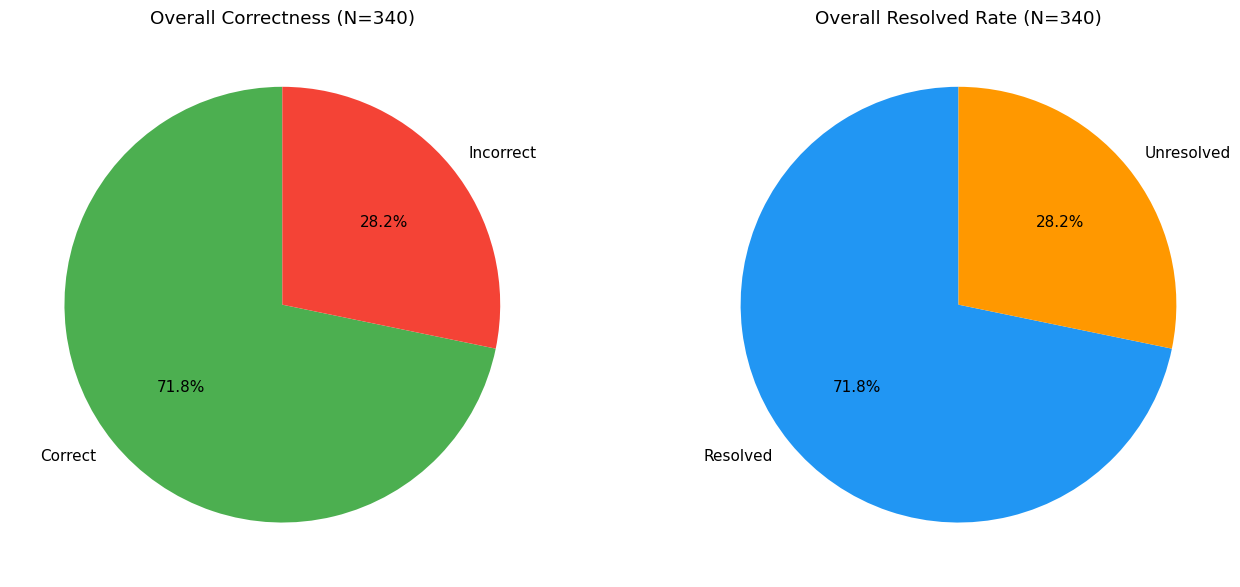

In [6]:
# Pie chart: Overall correctness distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Correctness
labels_corr = ['Correct', 'Incorrect']
sizes_corr = [total_correct, total_incorrect]
colors_corr = ['#4CAF50', '#F44336']
if total_unknown > 0:
    labels_corr.append('Unknown')
    sizes_corr.append(total_unknown)
    colors_corr.append('#9E9E9E')

axes[0].pie(sizes_corr, labels=labels_corr, colors=colors_corr, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Overall Correctness (N={total_all})')

# Right: Resolved
labels_res = ['Resolved', 'Unresolved']
sizes_res = [total_resolved, total_all - total_resolved]
colors_res = ['#2196F3', '#FF9800']

axes[1].pie(sizes_res, labels=labels_res, colors=colors_res, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Overall Resolved Rate (N={total_all})')

plt.tight_layout()
plt.show()

## 4. Model Statistics

Breakdown by model used for trajectory generation.

In [7]:
# Model statistics
model_stats = defaultdict(lambda: Counter())
model_resolved = defaultdict(lambda: {'resolved': 0, 'unresolved': 0})

for sample in all_data:
    model = sample['model']
    correctness = sample['correctness']
    model_stats[model][correctness] += 1
    if sample['resolved']:
        model_resolved[model]['resolved'] += 1
    else:
        model_resolved[model]['unresolved'] += 1

print('=' * 100)
print(f'{"Model":<40} {"#Trajectories":>14} {"#Correct":>9} {"#Incorrect":>11} {"Resolved%":>10}')
print('=' * 100)

for model in sorted(model_stats.keys()):
    counts = model_stats[model]
    total = sum(counts.values())
    correct = counts.get('correct', 0)
    incorrect = counts.get('incorrect', 0)
    resolved = model_resolved[model]['resolved']
    resolved_pct = resolved / total * 100 if total > 0 else 0
    print(f'{model:<40} {total:>14,} {correct:>9,} {incorrect:>11,} {resolved_pct:>9.1f}%')

print('=' * 100)

Model                                     #Trajectories  #Correct  #Incorrect  Resolved%
openai/Qwen3-Coder-Next                             340       244          96      71.8%


## 5. Token Length Distribution

Compute token length statistics:
- Per repo: total, system, user, assistant, tool
- Overall distribution

In [8]:
# Build token length data structures
repo_token_stats = defaultdict(lambda: {'total': [], 'system': [], 'user': [], 'assistant': [], 'tool': []})
overall_token_stats = {'total': [], 'system': [], 'user': [], 'assistant': [], 'tool': []}

for sample in all_data:
    repo = sample['repo']
    msg_info = sample['msg_token_info']
    
    total_tokens = 0
    system_tokens = 0
    user_tokens = 0
    assistant_tokens = 0
    tool_tokens = 0
    
    for role, tc in msg_info:
        total_tokens += tc
        if role == 'system':
            system_tokens += tc
        elif role == 'user':
            user_tokens += tc
        elif role == 'assistant':
            assistant_tokens += tc
        elif role == 'tool':
            tool_tokens += tc
    
    repo_token_stats[repo]['total'].append(total_tokens)
    repo_token_stats[repo]['system'].append(system_tokens)
    repo_token_stats[repo]['user'].append(user_tokens)
    repo_token_stats[repo]['assistant'].append(assistant_tokens)
    repo_token_stats[repo]['tool'].append(tool_tokens)
    
    overall_token_stats['total'].append(total_tokens)
    overall_token_stats['system'].append(system_tokens)
    overall_token_stats['user'].append(user_tokens)
    overall_token_stats['assistant'].append(assistant_tokens)
    overall_token_stats['tool'].append(tool_tokens)

print(f'Token stats computed for {len(repo_token_stats)} repos.')

Token stats computed for 9 repos.


### 5.1 Overall Token Length Summary

In [9]:
def compute_stats(values):
    """Compute mean, min, max, median, std for a list of values."""
    if not values:
        return 0, 0, 0, 0, 0
    return int(np.mean(values)), int(np.min(values)), int(np.max(values)), int(np.median(values)), int(np.std(values))

print('Overall Token Length Distribution (tokens per sample)')
print('=' * 90)
print(f'{"Role":<12} {"Mean":>8} {"Min":>8} {"Max":>8} {"Median":>8} {"Std":>8}')
print('-' * 90)
for role in ['total', 'system', 'user', 'assistant', 'tool']:
    mean, mn, mx, med, std = compute_stats(overall_token_stats[role])
    print(f'{role:<12} {mean:>8,} {mn:>8,} {mx:>8,} {med:>8,} {std:>8,}')
print('=' * 90)

Overall Token Length Distribution (tokens per sample)
Role             Mean      Min      Max   Median      Std
------------------------------------------------------------------------------------------
total          38,049    1,596  130,801   32,688   21,622
system             15       15       15       15        0
user              548      290    3,320      519      227
assistant       5,398       25   53,621    2,076    7,321
tool           32,087      949  124,952   27,510   17,689


### 5.2 Per-Repo Token Length Summary Table

In [10]:
# Build DataFrame for per-repo token stats
rows = []
for repo in sorted(repo_token_stats.keys()):
    stats = repo_token_stats[repo]
    n = len(stats['total'])
    total_mean, total_min, total_max, _, _ = compute_stats(stats['total'])
    sys_mean, sys_min, sys_max, _, _ = compute_stats(stats['system'])
    user_mean, user_min, user_max, _, _ = compute_stats(stats['user'])
    asst_mean, asst_min, asst_max, _, _ = compute_stats(stats['assistant'])
    tool_mean, tool_min, tool_max, _, _ = compute_stats(stats['tool'])
    rows.append({
        'Repo': repo, 'N': n,
        'Total_Mean': total_mean, 'Total_Min': total_min, 'Total_Max': total_max,
        'System_Mean': sys_mean, 'System_Min': sys_min, 'System_Max': sys_max,
        'User_Mean': user_mean, 'User_Min': user_min, 'User_Max': user_max,
        'Assistant_Mean': asst_mean, 'Assistant_Min': asst_min, 'Assistant_Max': asst_max,
        'Tool_Mean': tool_mean, 'Tool_Min': tool_min, 'Tool_Max': tool_max,
    })

df_repo = pd.DataFrame(rows)

print('Token Length Distribution per Repo (tokens per sample)')
print('=' * 160)
print(f'{"Repo":<35} {"N":>4} | {"Total":^19} | {"System":^19} | {"User":^19} | {"Assistant":^19} | {"Tool":^19}')
print(f'{"":<35} {"":>4} | {"Mean":>6} {"Min":>5} {"Max":>6} | {"Mean":>6} {"Min":>5} {"Max":>6} | {"Mean":>6} {"Min":>5} {"Max":>6} | {"Mean":>6} {"Min":>5} {"Max":>6} | {"Mean":>6} {"Min":>5} {"Max":>6}')
print('-' * 160)
for _, row in df_repo.iterrows():
    repo_name = row['Repo'][:33]
    print(f'{repo_name:<35} {row["N"]:>4} | '
          f'{row["Total_Mean"]:>6,} {row["Total_Min"]:>5,} {row["Total_Max"]:>6,} | '
          f'{row["System_Mean"]:>6,} {row["System_Min"]:>5,} {row["System_Max"]:>6,} | '
          f'{row["User_Mean"]:>6,} {row["User_Min"]:>5,} {row["User_Max"]:>6,} | '
          f'{row["Assistant_Mean"]:>6,} {row["Assistant_Min"]:>5,} {row["Assistant_Max"]:>6,} | '
          f'{row["Tool_Mean"]:>6,} {row["Tool_Min"]:>5,} {row["Tool_Max"]:>6,}')
print('=' * 160)

Token Length Distribution per Repo (tokens per sample)
Repo                                   N |        Total        |       System        |        User         |      Assistant      |        Tool        
                                         |   Mean   Min    Max |   Mean   Min    Max |   Mean   Min    Max |   Mean   Min    Max |   Mean   Min    Max
----------------------------------------------------------------------------------------------------------------------------------------------------------------
NodeBB/NodeBB                         40 | 39,626 9,670 86,901 |     15    15     15 |    632   378  3,320 |  4,557   558 27,122 | 34,421 8,453 71,986
ansible/ansible                       33 | 29,475 10,721 70,156 |     15    15     15 |    689   520  1,145 |  2,498   543 13,167 | 26,273 9,292 58,153
element-hq/element-web                56 | 30,949 10,451 96,306 |     15    15     15 |    539   322    887 |  3,461   443 22,701 | 26,932 8,691 93,852
flipt-io/flipt             

In [11]:
# Display as styled pandas DataFrame
display_df = df_repo.set_index('Repo')
display_df.columns = pd.MultiIndex.from_tuples([
    ('Count', 'N'),
    ('Total', 'Mean'), ('Total', 'Min'), ('Total', 'Max'),
    ('System', 'Mean'), ('System', 'Min'), ('System', 'Max'),
    ('User', 'Mean'), ('User', 'Min'), ('User', 'Max'),
    ('Assistant', 'Mean'), ('Assistant', 'Min'), ('Assistant', 'Max'),
    ('Tool', 'Mean'), ('Tool', 'Min'), ('Tool', 'Max'),
])
display_df

Count  Total                System         User  \
                                N   Mean    Min     Max   Mean Min Max Mean   
Repo                                                                          
NodeBB/NodeBB                  40  39626   9670   86901     15  15  15  632   
ansible/ansible                33  29475  10721   70156     15  15  15  689   
element-hq/element-web         56  30949  10451   96306     15  15  15  539   
flipt-io/flipt                 38  59132  22148  100201     15  15  15  534   
future-architect/vuls          25  29013   9734   76009     15  15  15  460   
gravitational/teleport         30  38739   1596  130801     15  15  15  400   
internetarchive/openlibrary    35  28501  13572   68293     15  15  15  665   
navidrome/navidrome            33  55647   9021  105397     15  15  15  565   
qutebrowser/qutebrowser        50  33546  10752   77657     15  15  15  449   

                                       Assistant                Tool         \
                             Min   Max      Mean   Min    Max   Mean    Min   
Repo                                                                          
NodeBB/NodeBB                378  3320      4557   558  27122  34421   8453   
ansible/ansible              520  1145      2498   543  13167  26273   9292   
element-hq/element-web       322   887      3461   443  22701  26932   8691   
flipt-io/flipt               371   807     14001  2650  33796  44581  15010   
future-architect/vuls        290  1112      1777    85   6280  26760   7310   
gravitational/teleport       299   905      2737    25  11331  35585    949   
internetarchive/openlibrary  340  1824      1675   573   6220  26146  12359   
navidrome/navidrome          374  1005     15633   483  53621  39433   7947   
qutebrowser/qutebrowser      297   903      2875   591  15248  30206   8988   

                                     
                                Max  
Repo                                 
NodeBB/NodeBB                 71986  
ansible/ansible               58153  
element-hq/element-web        93852  
flipt-io/flipt                88697  
future-architect/vuls         69410  
gravitational/teleport       124952  
internetarchive/openlibrary   63413  
navidrome/navidrome           93053  
qutebrowser/qutebrowser       74316

### 5.3 Token Length Distribution (Visualization)

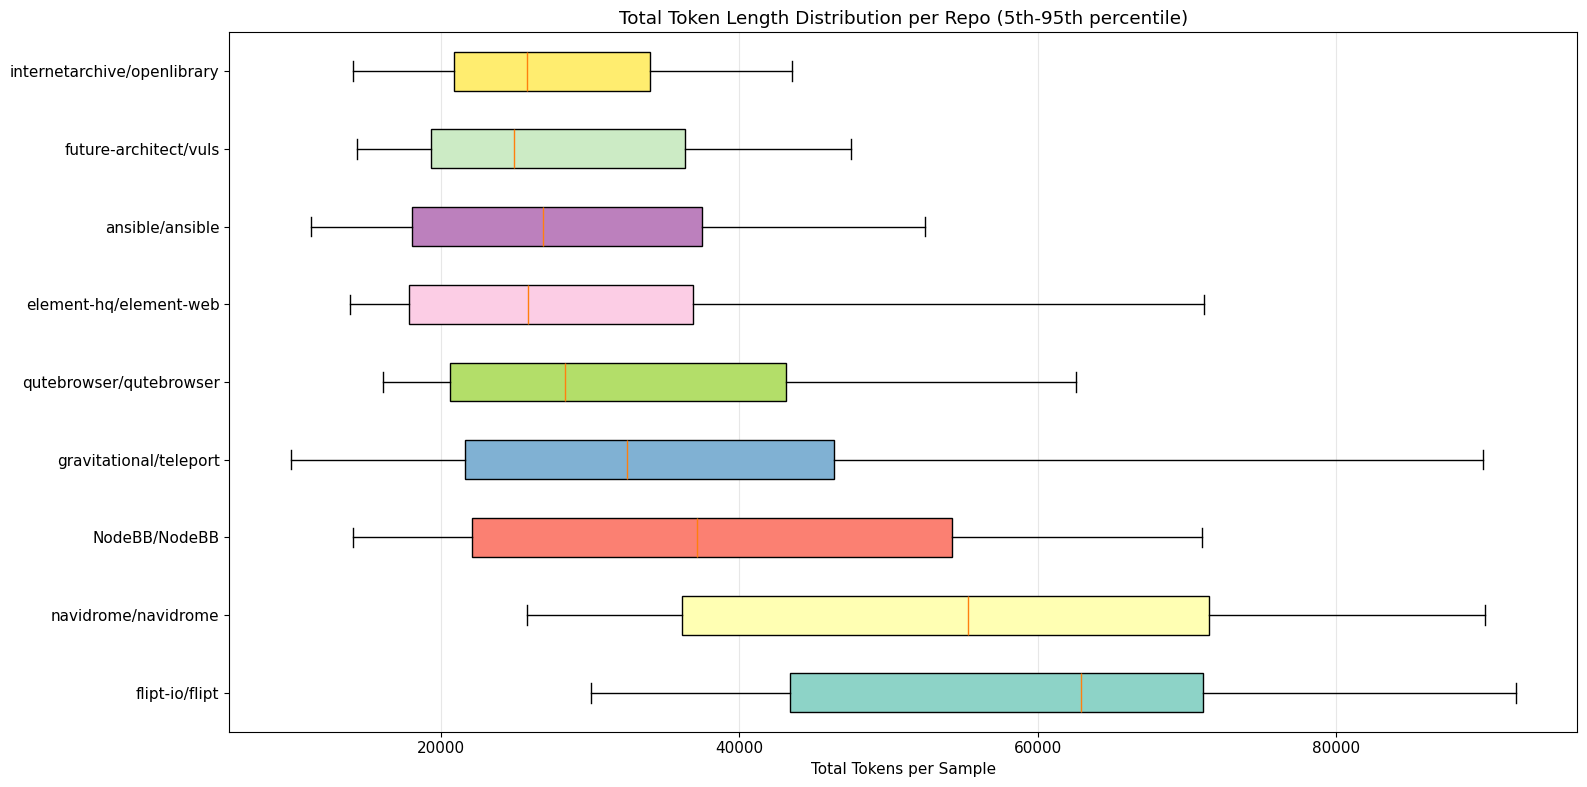

In [12]:
# Box plot: Total token length distribution per repo
fig, ax = plt.subplots(figsize=(16, 8))

repos_vis = sorted(repo_token_stats.keys(), key=lambda r: np.mean(repo_token_stats[r]['total']), reverse=True)
data_to_plot = [repo_token_stats[repo]['total'] for repo in repos_vis]
repo_labels = [str(r)[:35] for r in repos_vis]

bp = ax.boxplot(data_to_plot, vert=False, tick_labels=repo_labels, patch_artist=True, showfliers=False, whis=[5, 95])
colors_bp = plt.cm.Set3(np.linspace(0, 1, len(repos_vis)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax.set_xlabel('Total Tokens per Sample')
ax.set_title('Total Token Length Distribution per Repo (5th-95th percentile)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

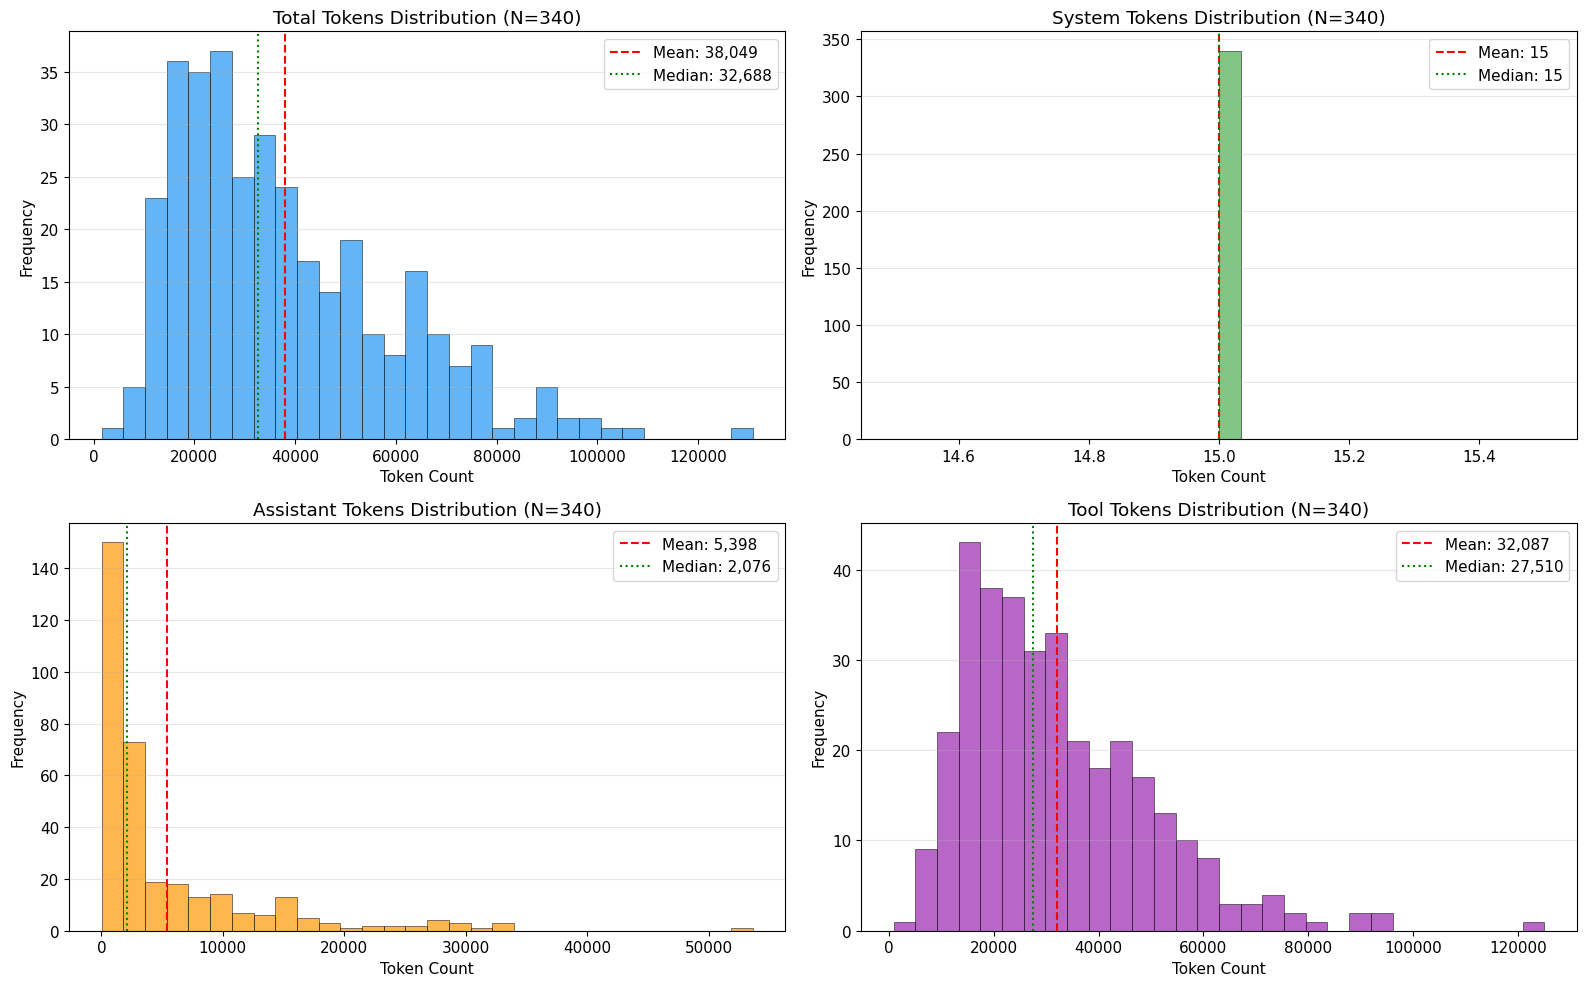

In [13]:
# Histogram: Overall total token length distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

roles_to_plot = ['total', 'system', 'assistant', 'tool']
titles = ['Total Tokens', 'System Tokens', 'Assistant Tokens', 'Tool Tokens']
colors_hist = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for idx, (role, title, color) in enumerate(zip(roles_to_plot, titles, colors_hist)):
    ax = axes[idx // 2][idx % 2]
    data = overall_token_stats[role]
    ax.hist(data, bins=30, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {int(np.mean(data)):,}')
    ax.axvline(np.median(data), color='green', linestyle=':', linewidth=1.5, label=f'Median: {int(np.median(data)):,}')
    ax.set_xlabel('Token Count')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title} Distribution (N={len(data)})')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

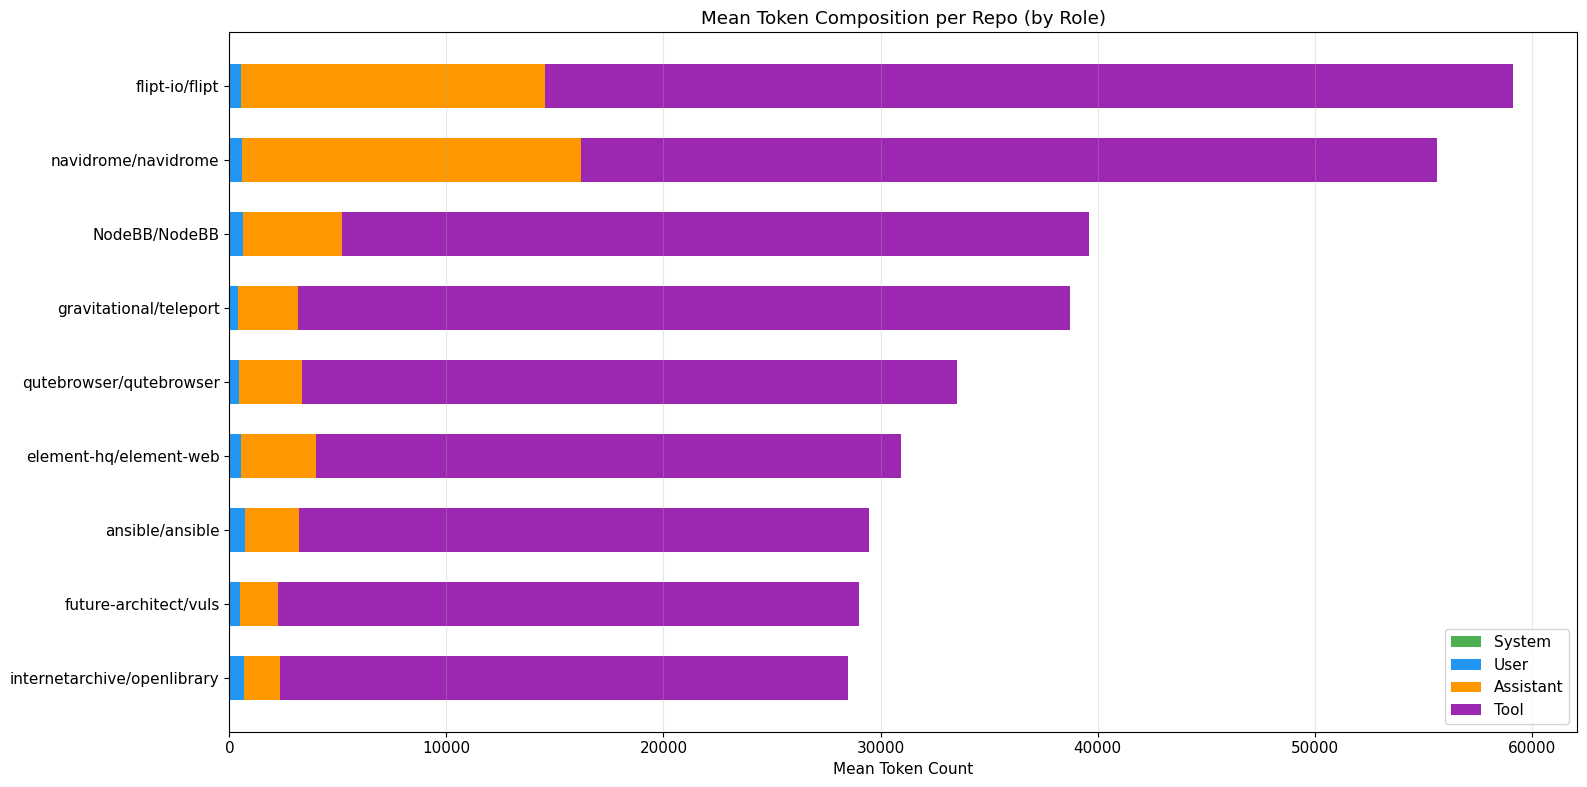

In [14]:
# Stacked bar chart: Token composition per repo (mean)
fig, ax = plt.subplots(figsize=(16, 8))

repos_vis = sorted(repo_token_stats.keys(), key=lambda r: np.mean(repo_token_stats[r]['total']), reverse=True)

system_means = [int(np.mean(repo_token_stats[r]['system'])) for r in repos_vis]
user_means = [int(np.mean(repo_token_stats[r]['user'])) for r in repos_vis]
assistant_means = [int(np.mean(repo_token_stats[r]['assistant'])) for r in repos_vis]
tool_means = [int(np.mean(repo_token_stats[r]['tool'])) for r in repos_vis]

y_pos = np.arange(len(repos_vis))
bar_height = 0.6

ax.barh(y_pos, system_means, bar_height, color='#4CAF50', label='System')
ax.barh(y_pos, user_means, bar_height, left=system_means, color='#2196F3', label='User')
left_2 = [s + u for s, u in zip(system_means, user_means)]
ax.barh(y_pos, assistant_means, bar_height, left=left_2, color='#FF9800', label='Assistant')
left_3 = [l + a for l, a in zip(left_2, assistant_means)]
ax.barh(y_pos, tool_means, bar_height, left=left_3, color='#9C27B0', label='Tool')

ax.set_yticks(y_pos)
ax.set_yticklabels([str(r)[:35] for r in repos_vis])
ax.set_xlabel('Mean Token Count')
ax.set_title('Mean Token Composition per Repo (by Role)')
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Message Count Distribution

Analyze the number of messages (turns) per trajectory.

Message Count Statistics:
  Mean: 80.9
  Median: 76.0
  Min: 4
  Max: 230
  Std: 38.6


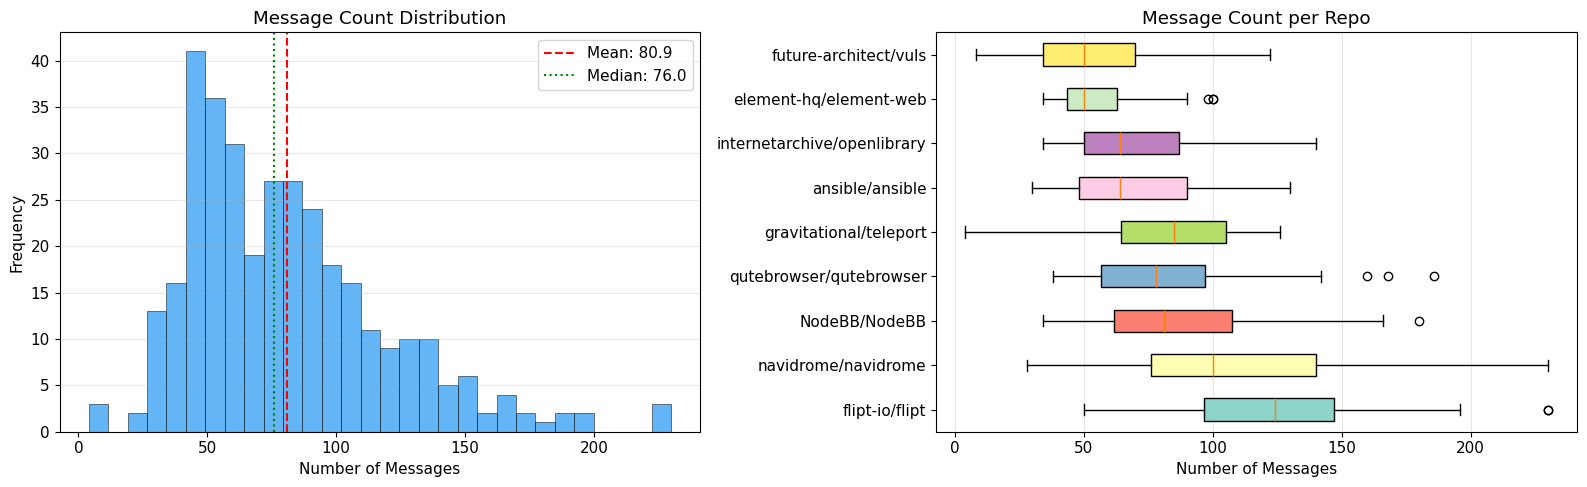

In [15]:
# Message count statistics
msg_counts = [s['num_messages'] for s in all_data]

print('Message Count Statistics:')
print(f'  Mean: {np.mean(msg_counts):.1f}')
print(f'  Median: {np.median(msg_counts):.1f}')
print(f'  Min: {np.min(msg_counts)}')
print(f'  Max: {np.max(msg_counts)}')
print(f'  Std: {np.std(msg_counts):.1f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Histogram of message counts
axes[0].hist(msg_counts, bins=30, color='#2196F3', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axvline(np.mean(msg_counts), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(msg_counts):.1f}')
axes[0].axvline(np.median(msg_counts), color='green', linestyle=':', linewidth=1.5, label=f'Median: {np.median(msg_counts):.1f}')
axes[0].set_xlabel('Number of Messages')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Message Count Distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: Box plot per repo
repo_msg_counts = defaultdict(list)
for s in all_data:
    repo_msg_counts[s['repo']].append(s['num_messages'])

repos_vis = sorted(repo_msg_counts.keys(), key=lambda r: np.mean(repo_msg_counts[r]), reverse=True)
data_msg = [repo_msg_counts[r] for r in repos_vis]
labels_msg = [str(r)[:35] for r in repos_vis]

bp = axes[1].boxplot(data_msg, vert=False, tick_labels=labels_msg, patch_artist=True, showfliers=True)
colors_bp = plt.cm.Set3(np.linspace(0, 1, len(repos_vis)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
axes[1].set_xlabel('Number of Messages')
axes[1].set_title('Message Count per Repo')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Correctness vs Token Length

Analyze whether there is a relationship between token length and correctness.

Token Length by Correctness:
  Correct   (N=244): Mean=  39,038, Median=  33,348, Std=  21,698
  Incorrect (N= 96): Mean=  35,534, Median=  28,839, Std=  21,220


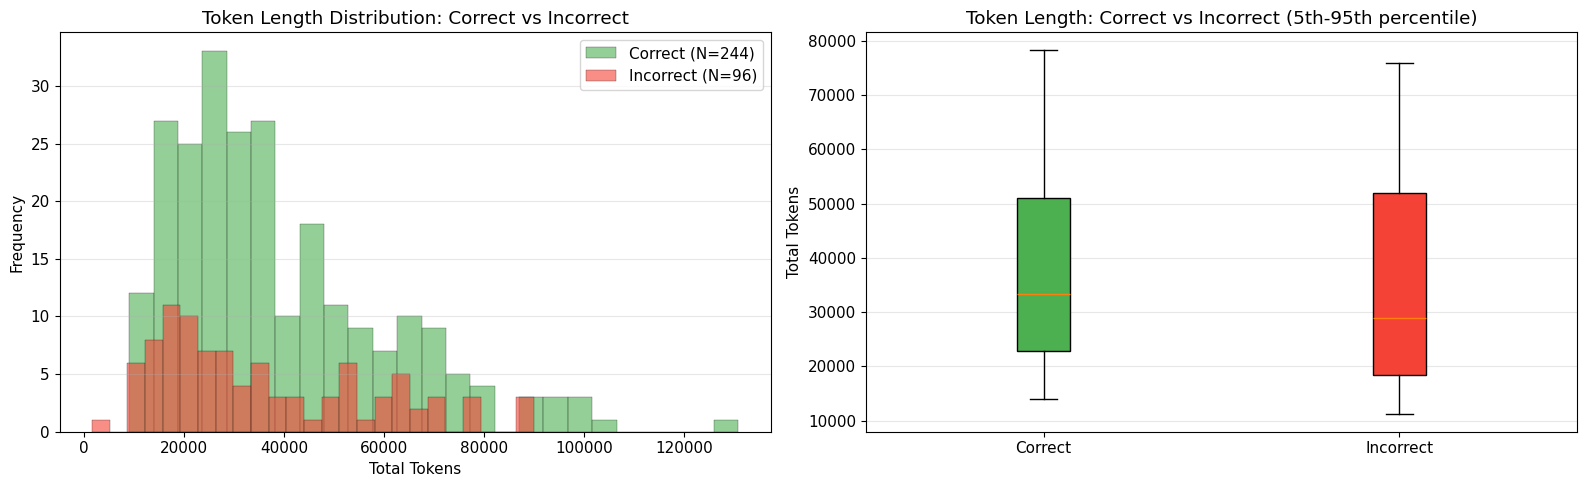

In [16]:
# Compare token lengths for correct vs incorrect trajectories
correct_tokens = [overall_token_stats['total'][i] for i, s in enumerate(all_data) if s['correctness'] == 'correct']
incorrect_tokens = [overall_token_stats['total'][i] for i, s in enumerate(all_data) if s['correctness'] == 'incorrect']

print('Token Length by Correctness:')
print(f'  Correct   (N={len(correct_tokens):>3}): Mean={int(np.mean(correct_tokens)):>8,}, Median={int(np.median(correct_tokens)):>8,}, Std={int(np.std(correct_tokens)):>8,}')
print(f'  Incorrect (N={len(incorrect_tokens):>3}): Mean={int(np.mean(incorrect_tokens)):>8,}, Median={int(np.median(incorrect_tokens)):>8,}, Std={int(np.std(incorrect_tokens)):>8,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Overlapping histograms
axes[0].hist(correct_tokens, bins=25, color='#4CAF50', alpha=0.6, label=f'Correct (N={len(correct_tokens)})', edgecolor='black', linewidth=0.3)
axes[0].hist(incorrect_tokens, bins=25, color='#F44336', alpha=0.6, label=f'Incorrect (N={len(incorrect_tokens)})', edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Total Tokens')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Token Length Distribution: Correct vs Incorrect')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: Box plot comparison
bp = axes[1].boxplot([correct_tokens, incorrect_tokens], tick_labels=['Correct', 'Incorrect'], 
                     patch_artist=True, showfliers=False, whis=[5, 95])
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#F44336')
axes[1].set_ylabel('Total Tokens')
axes[1].set_title('Token Length: Correct vs Incorrect (5th-95th percentile)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary

Key findings from the SHINE_SWE_Pro dataset analysis.

In [17]:
print('=' * 70)
print('SHINE_SWE_Pro Dataset Summary')
print('=' * 70)
print(f'Total samples:          {total_all:,}')
print(f'Unique repos:           {len(repo_token_stats)}')
print(f'Unique models:          {len(model_stats)}')
print(f'Correct trajectories:   {total_correct:,} ({total_correct/total_all*100:.1f}%)')
print(f'Incorrect trajectories: {total_incorrect:,} ({total_incorrect/total_all*100:.1f}%)')
print(f'Resolved trajectories:  {total_resolved:,} ({total_resolved_pct:.1f}%)')
print(f'\nToken Statistics (per sample):')
print(f'  Total:     Mean={int(np.mean(overall_token_stats["total"])):>8,}, Median={int(np.median(overall_token_stats["total"])):>8,}')
print(f'  System:    Mean={int(np.mean(overall_token_stats["system"])):>8,}, Median={int(np.median(overall_token_stats["system"])):>8,}')
print(f'  User:      Mean={int(np.mean(overall_token_stats["user"])):>8,}, Median={int(np.median(overall_token_stats["user"])):>8,}')
print(f'  Assistant: Mean={int(np.mean(overall_token_stats["assistant"])):>8,}, Median={int(np.median(overall_token_stats["assistant"])):>8,}')
print(f'  Tool:      Mean={int(np.mean(overall_token_stats["tool"])):>8,}, Median={int(np.median(overall_token_stats["tool"])):>8,}')
print(f'\nMessage Count (per sample):')
print(f'  Mean={np.mean(msg_counts):.1f}, Median={np.median(msg_counts):.1f}, Min={np.min(msg_counts)}, Max={np.max(msg_counts)}')
print('=' * 70)

SHINE_SWE_Pro Dataset Summary
Total samples:          340
Unique repos:           9
Unique models:          1
Correct trajectories:   244 (71.8%)
Incorrect trajectories: 96 (28.2%)
Resolved trajectories:  244 (71.8%)

Token Statistics (per sample):
  Total:     Mean=  38,049, Median=  32,688
  System:    Mean=      15, Median=      15
  User:      Mean=     548, Median=     519
  Assistant: Mean=   5,398, Median=   2,076
  Tool:      Mean=  32,087, Median=  27,510

Message Count (per sample):
  Mean=80.9, Median=76.0, Min=4, Max=230
